<a href="https://colab.research.google.com/github/PratamaAngga/Data-Mining-Course/blob/main/Diabetes-dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SOAL 1 - PRAKTIKUM JOBSHEET: DATA TITANIC
✅ Data berhasil diload dari URL

Shape Train: (624, 12)
Shape Test : (267, 11)

--- INFO DATASET ---
<class 'pandas.core.frame.DataFrame'>
Index: 624 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  624 non-null    int64  
 1   Survived     624 non-null    int64  
 2   Pclass       624 non-null    int64  
 3   Name         624 non-null    object 
 4   Sex          624 non-null    object 
 5   Age          500 non-null    float64
 6   SibSp        624 non-null    int64  
 7   Parch        624 non-null    int64  
 8   Ticket       624 non-null    object 
 9   Fare         624 non-null    float64
 10  Cabin        140 non-null    object 
 11  Embarked     623 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 63.4+ KB
None

--- SAMPLE DATA ---
     PassengerId  Survived  Pclass                        Name     Sex   Age  \


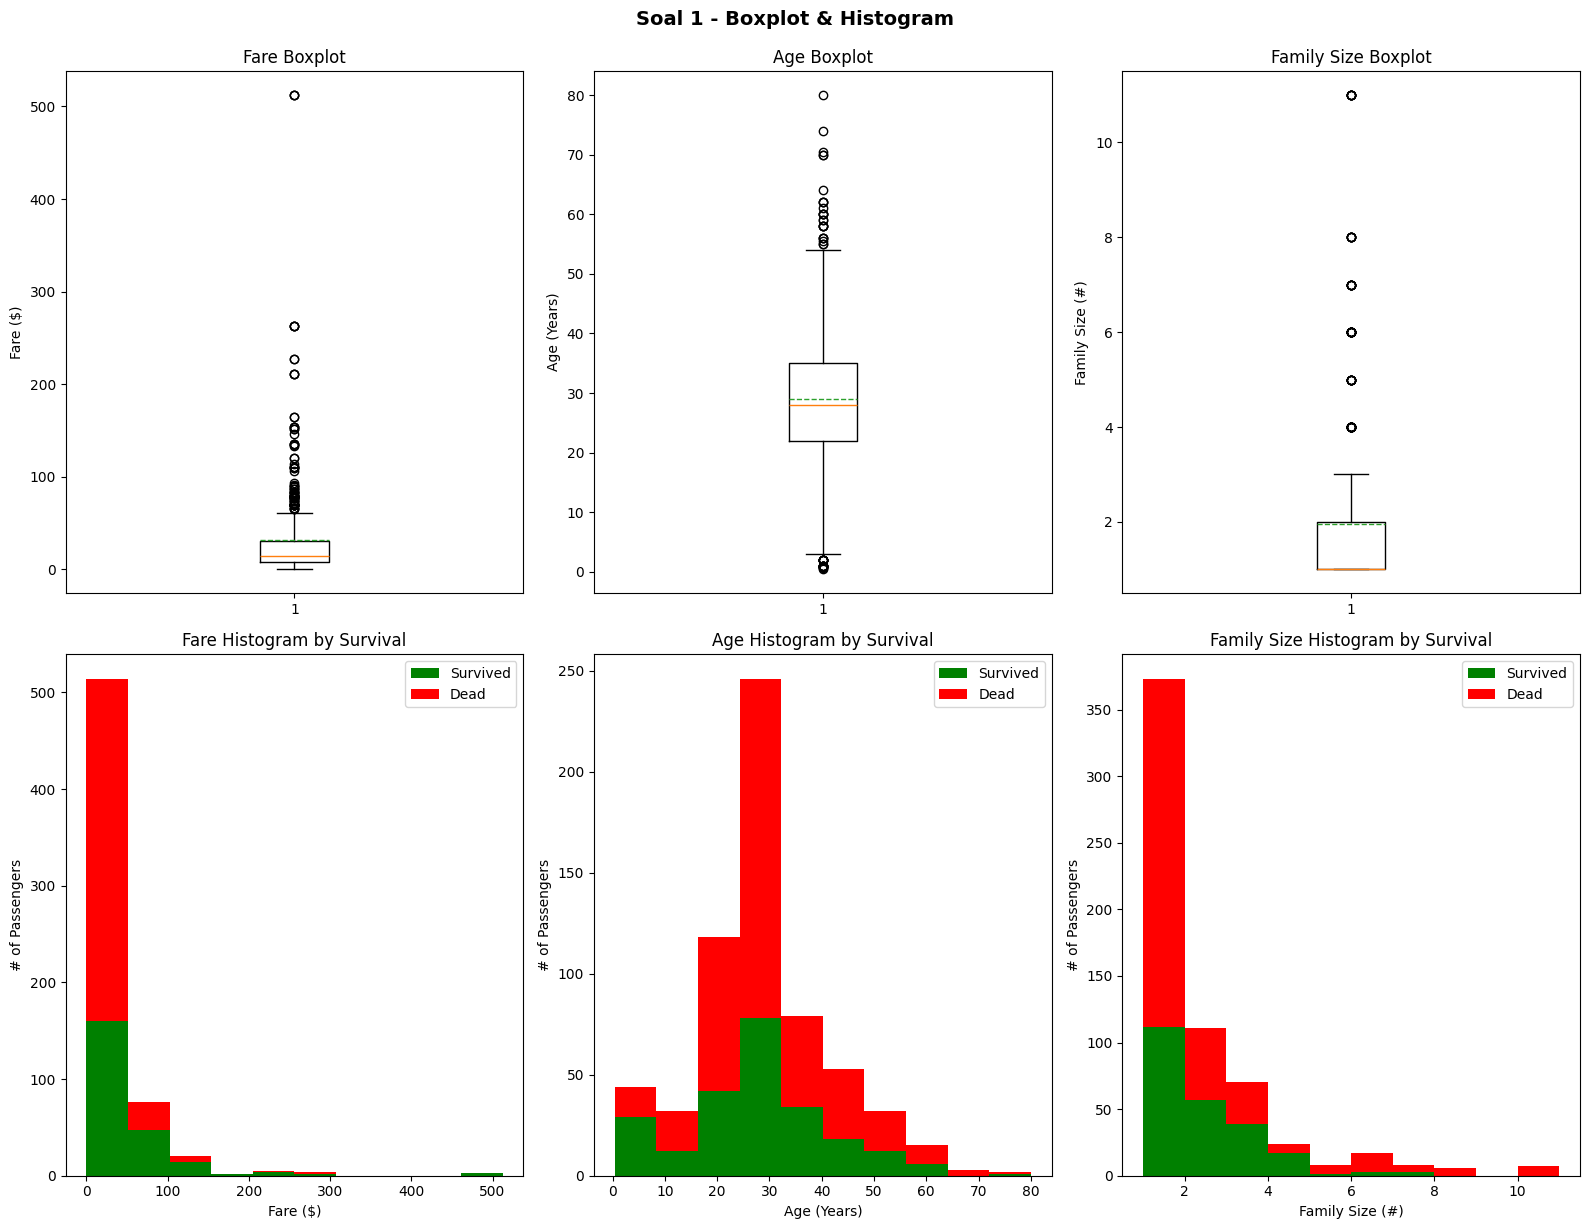

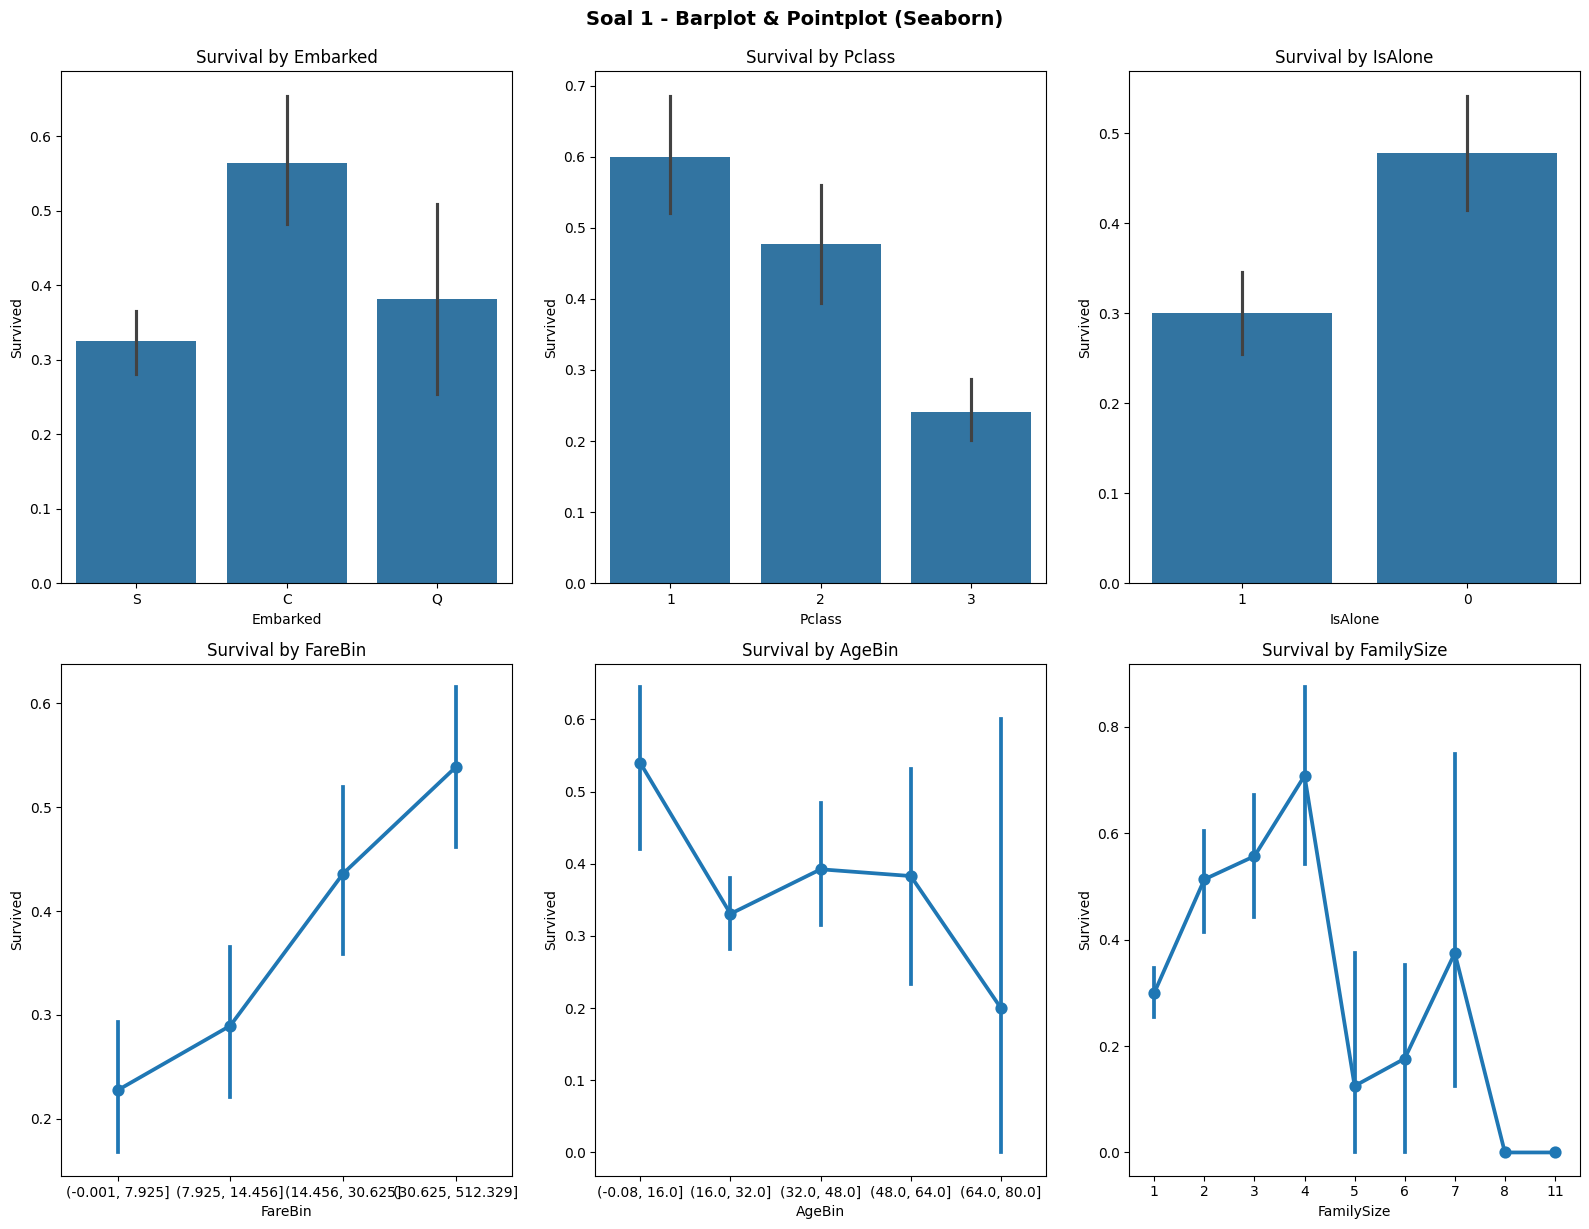

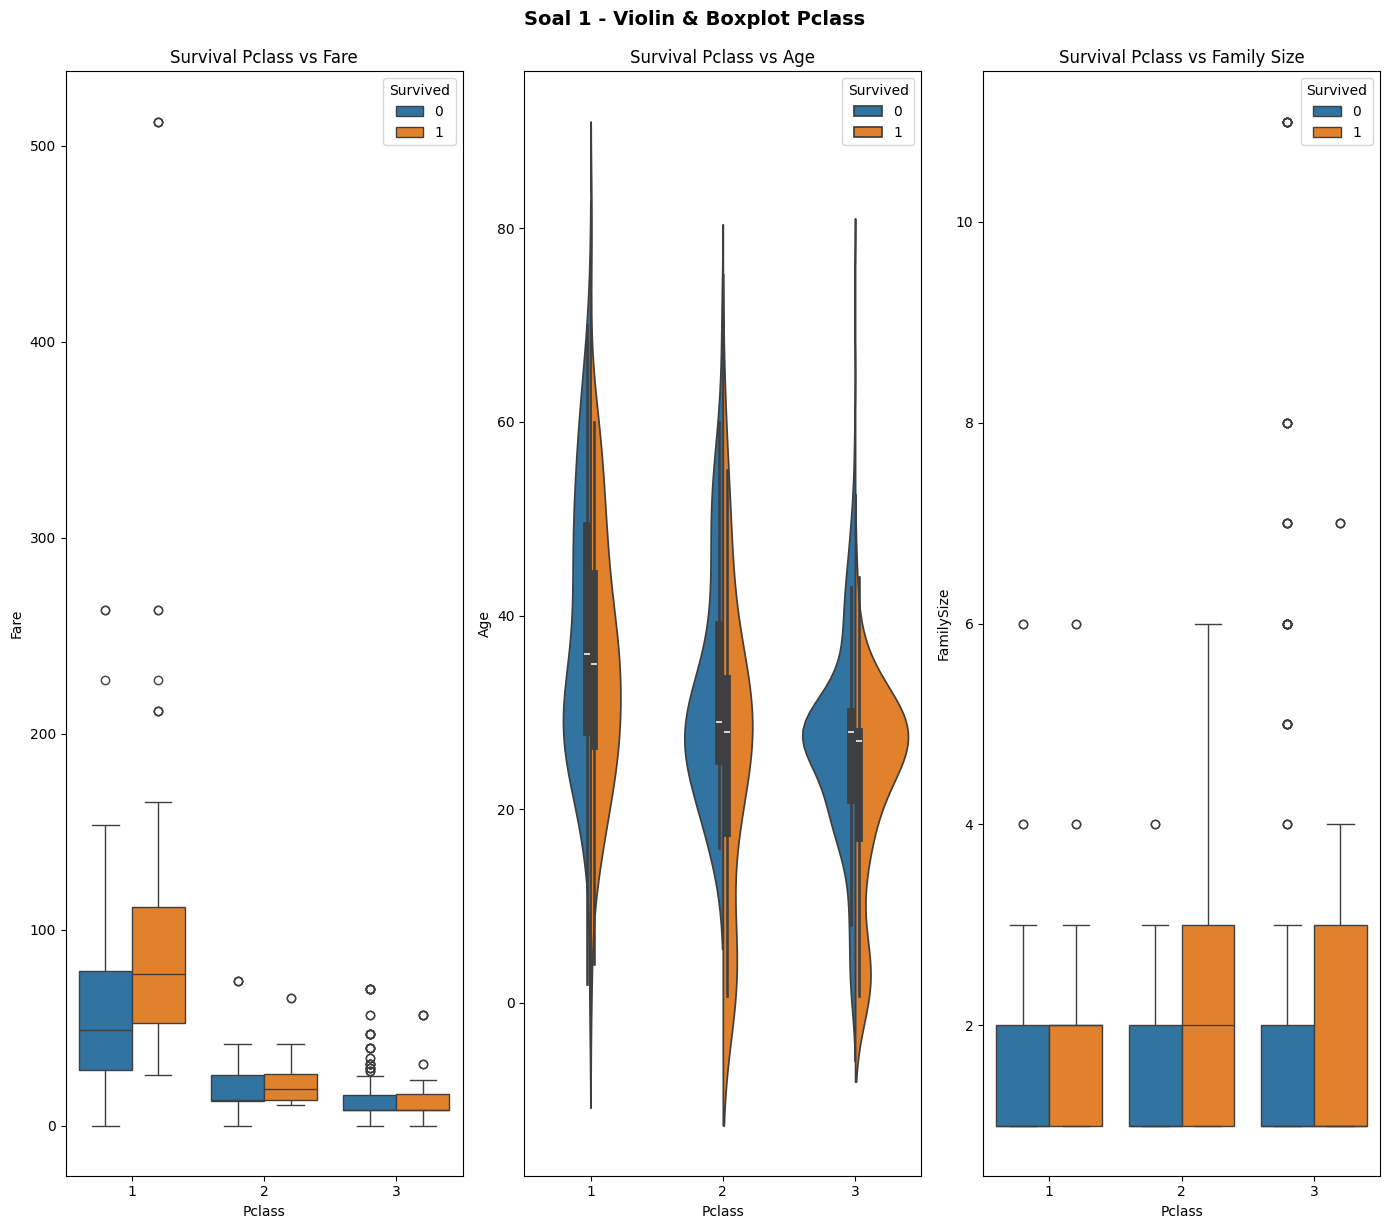

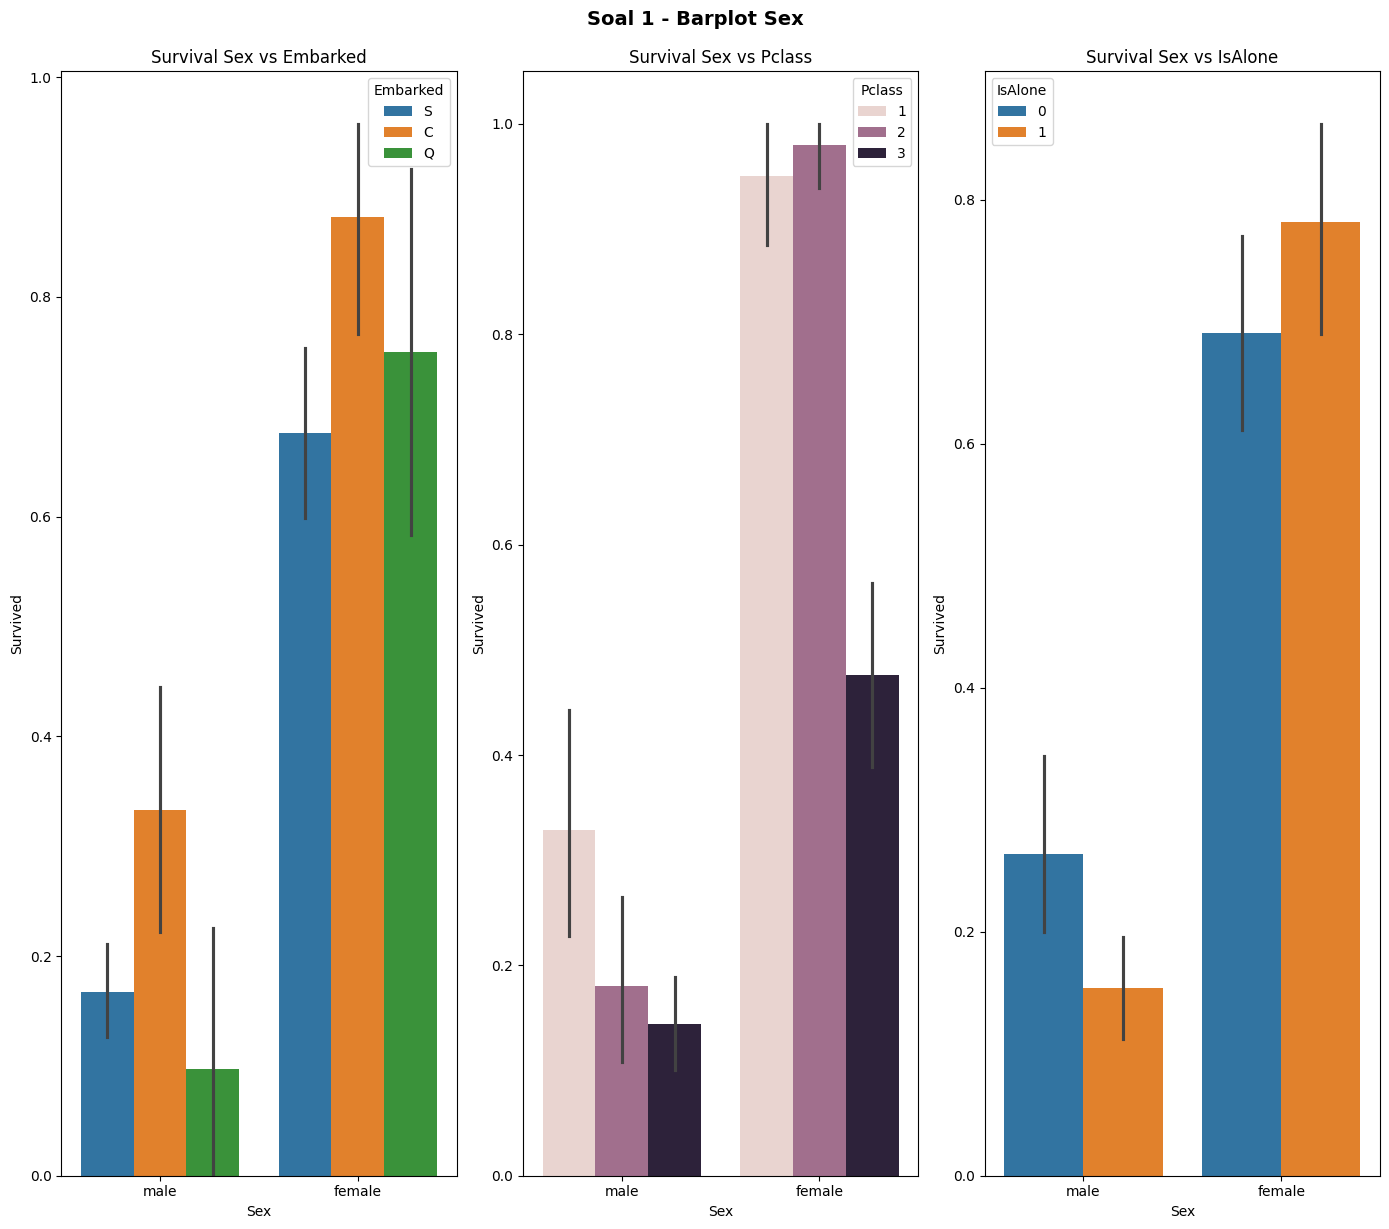

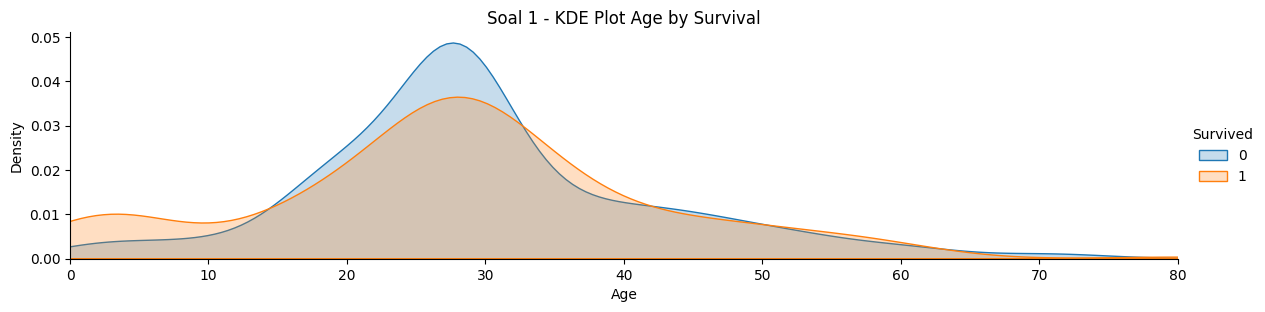

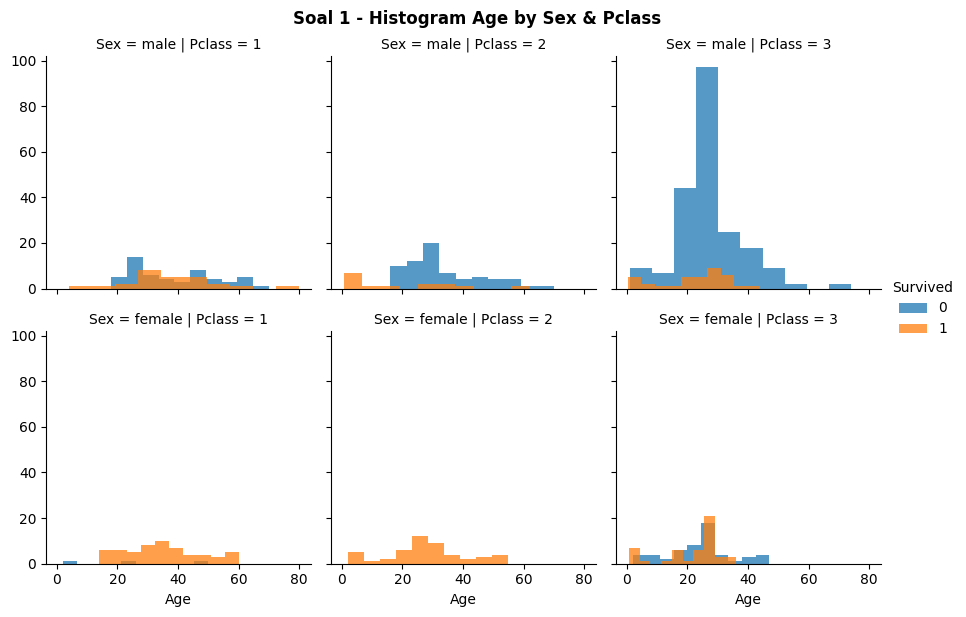

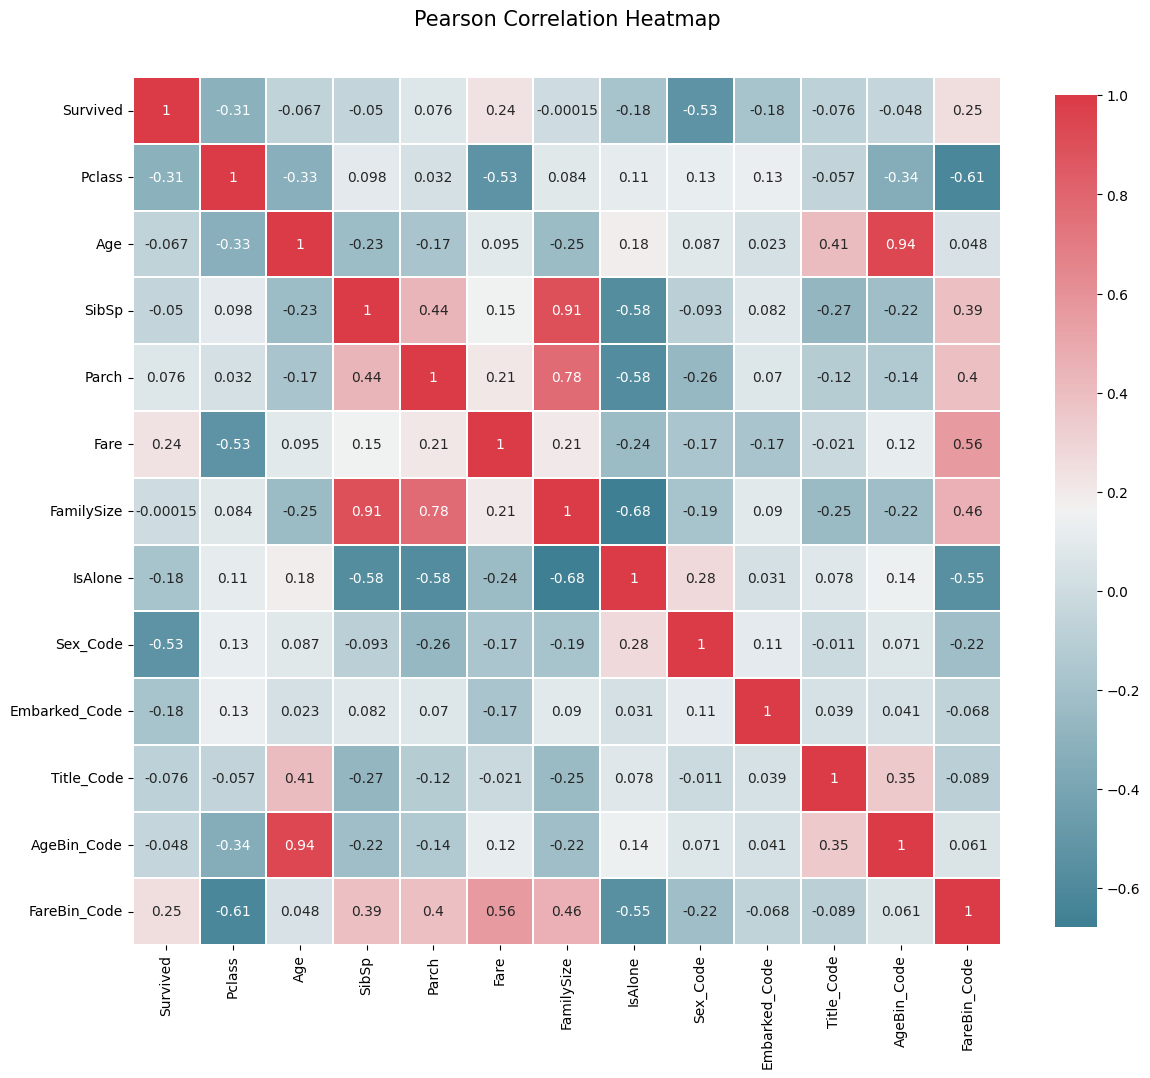


✅ Soal 1 selesai!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import model_selection
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# SOAL 1 - Praktikum sesuai jobsheet
# (Data Cleaning + Feature Engineering + Visualisasi Titanic)
# ============================================================

print("=" * 60)
print("SOAL 1 - PRAKTIKUM JOBSHEET: DATA TITANIC")
print("=" * 60)

# ----------------------------------------------------------
# TAHAP 2: Load Data
# ----------------------------------------------------------
# Opsi A: Load dari Google Drive (sesuai jobsheet)
# from google.colab import drive
# drive.mount('/content/drive')
# data_raw = pd.read_csv('/content/drive/MyDrive/Kuliah/2025 Data Mining/Dataset/Titanic/train.csv')
# data_val  = pd.read_csv('/content/drive/MyDrive/Kuliah/2025 Data Mining/Dataset/Titanic/test.csv')

# Opsi B: Download langsung (lebih praktis)
# !pip install kaggle -q
# Letakkan file kaggle.json ke /root/.kaggle/ lalu:
# !kaggle competitions download -c titanic -p /content/
# !unzip /content/titanic.zip -d /content/titanic/
# data_raw = pd.read_csv('/content/titanic/train.csv')
# data_val  = pd.read_csv('/content/titanic/test.csv')

# Opsi C: Buat data simulasi (TANPA download, langsung jalan)
# HAPUS BLOK INI dan gunakan Opsi A/B jika sudah punya filenya
from io import StringIO
import urllib.request

url_train = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
try:
    data_raw = pd.read_csv(url_train)
    # Simulasi split train/test
    data_val = data_raw.sample(frac=0.3, random_state=42).drop(columns=['Survived'])
    data_raw = data_raw.drop(data_val.index)
    print("✅ Data berhasil diload dari URL")
except:
    print("⚠️ Tidak bisa connect. Gunakan Opsi A atau B.")

print(f"\nShape Train: {data_raw.shape}")
print(f"Shape Test : {data_val.shape}")

# ----------------------------------------------------------
# TAHAP 3A: Memahami Data (info + sample)
# ----------------------------------------------------------
print("\n--- INFO DATASET ---")
print(data_raw.info())

print("\n--- SAMPLE DATA ---")
print(data_raw.sample(5))

# ----------------------------------------------------------
# TAHAP 3B: Cek NULL Values
# ----------------------------------------------------------
print("\n--- MISSING VALUES (TRAIN) ---")
print(data_raw.isnull().sum())
print("-" * 30)

print("\n--- MISSING VALUES (TEST) ---")
print(data_val.isnull().sum())
print("-" * 30)

print("\n--- STATISTIK DESKRIPTIF ---")
print(data_raw.describe(include='all'))

# ----------------------------------------------------------
# TAHAP 3C: 4C - Completing (isi nilai NULL)
# ----------------------------------------------------------
print("\n--- COMPLETING: Mengisi Missing Values ---")

# Gabungkan train dan test untuk cleaning konsisten
data1     = data_raw.copy(deep=True)
data_cleaner = [data1, data_val]

for dataset in data_cleaner:
    # Age: isi dengan median
    dataset['Age'].fillna(dataset['Age'].median(), inplace=True)
    # Embarked: isi dengan modus
    dataset['Embarked'].fillna(dataset['Embarked'].mode()[0], inplace=True)
    # Fare: isi dengan median
    dataset['Fare'].fillna(dataset['Fare'].median(), inplace=True)

# Hapus kolom yang tidak diperlukan
drop_column = ['PassengerId', 'Cabin', 'Ticket']
data1.drop(drop_column, axis=1, inplace=True)

print("Setelah Completing:")
print(data1.isnull().sum())

# ----------------------------------------------------------
# TAHAP 3D: Creating - Feature Engineering
# ----------------------------------------------------------
print("\n--- CREATING: Feature Engineering ---")

for dataset in data_cleaner:
    # FamilySize: ukuran keluarga total
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1

    # IsAlone: apakah penumpang sendirian?
    dataset['IsAlone'] = 1
    dataset.loc[dataset['FamilySize'] > 1, 'IsAlone'] = 0

    # Title: ekstrak gelar dari nama
    dataset['Title'] = dataset['Name'].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]

    # FareBin: buat bin fare
    dataset['FareBin'] = pd.qcut(dataset['Fare'], 4)

    # AgeBin: buat bin age
    dataset['AgeBin'] = pd.cut(dataset['Age'].astype(int), 5)

# Bersihkan Title yang jarang muncul
stat_min = 10
title_names = (data1['Title'].value_counts() < stat_min)
data1['Title'] = data1['Title'].apply(lambda x: 'Misc' if title_names.loc[x] == True else x)

print("Distribusi Title:")
print(data1['Title'].value_counts())
print("\nInfo data setelah feature engineering:")
print(data1.info())

# ----------------------------------------------------------
# TAHAP 3E: Converting - Encode kategorikal
# ----------------------------------------------------------
print("\n--- CONVERTING: Encoding Variabel Kategorikal ---")

label = LabelEncoder()
for dataset in data_cleaner:
    dataset['Sex_Code']      = label.fit_transform(dataset['Sex'])
    dataset['Embarked_Code'] = label.fit_transform(dataset['Embarked'])
    dataset['Title_Code']    = label.fit_transform(dataset['Title'])
    dataset['AgeBin_Code']   = label.fit_transform(dataset['AgeBin'])
    dataset['FareBin_Code']  = label.fit_transform(dataset['FareBin'])

print("Kolom setelah encoding:")
print(data1.columns.tolist())

# ----------------------------------------------------------
# TAHAP 4: Analisa Exploratory
# Target kolom
Target = ['Survived']
data1_x = ['Sex', 'Pclass', 'Embarked', 'Title', 'SibSp', 'Parch',
           'Age', 'Fare', 'FamilySize', 'IsAlone']
data1_x_calc = ['Sex_Code', 'Pclass', 'Embarked_Code', 'Title_Code',
                'SibSp', 'Parch', 'Age', 'Fare']
data1_xy = Target + data1_x
# ----------------------------------------------------------
print("\n--- KORELASI SURVIVAL DENGAN FITUR LAIN ---")

for x in data1_x:
    if data1[x].dtype != 'float64':
        print(f'Korelasi Survival dengan: {x}')
        print(data1[[x, Target[0]]].groupby(x, as_index=False).mean())
        print('-' * 10, '\n')

# Crosstab Title vs Survived
print("Crosstab Title vs Survived:")
print(pd.crosstab(data1['Title'], data1[Target[0]]))

# ----------------------------------------------------------
# VISUALISASI SOAL 1 (sesuai jobsheet)
# ----------------------------------------------------------
print("\n--- VISUALISASI (Jobsheet) ---")

# Boxplot + Histogram
plt.figure(figsize=(16, 12))

plt.subplot(231)
plt.boxplot(x=data1['Fare'], showmeans=True, meanline=True)
plt.title('Fare Boxplot')
plt.ylabel('Fare ($)')

plt.subplot(232)
plt.boxplot(x=data1['Age'], showmeans=True, meanline=True)
plt.title('Age Boxplot')
plt.ylabel('Age (Years)')

plt.subplot(233)
plt.boxplot(x=data1['FamilySize'], showmeans=True, meanline=True)
plt.title('Family Size Boxplot')
plt.ylabel('Family Size (#)')

plt.subplot(234)
plt.hist(x=[data1[data1['Survived']==1]['Fare'], data1[data1['Survived']==0]['Fare']],
         stacked=True, color=['g','r'], label=['Survived','Dead'])
plt.title('Fare Histogram by Survival')
plt.xlabel('Fare ($)')
plt.ylabel('# of Passengers')
plt.legend()

plt.subplot(235)
plt.hist(x=[data1[data1['Survived']==1]['Age'], data1[data1['Survived']==0]['Age']],
         stacked=True, color=['g','r'], label=['Survived','Dead'])
plt.title('Age Histogram by Survival')
plt.xlabel('Age (Years)')
plt.ylabel('# of Passengers')
plt.legend()

plt.subplot(236)
plt.hist(x=[data1[data1['Survived']==1]['FamilySize'], data1[data1['Survived']==0]['FamilySize']],
         stacked=True, color=['g','r'], label=['Survived','Dead'])
plt.title('Family Size Histogram by Survival')
plt.xlabel('Family Size (#)')
plt.ylabel('# of Passengers')
plt.legend()

plt.tight_layout()
plt.suptitle('Soal 1 - Boxplot & Histogram', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('soal1_boxplot_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

# Barplot seaborn
fig, saxis = plt.subplots(2, 3, figsize=(16, 12))

sns.barplot(x='Embarked',    y='Survived', data=data1, ax=saxis[0,0])
saxis[0,0].set_title('Survival by Embarked')
sns.barplot(x='Pclass',      y='Survived', order=[1,2,3], data=data1, ax=saxis[0,1])
saxis[0,1].set_title('Survival by Pclass')
sns.barplot(x='IsAlone',     y='Survived', order=[1,0], data=data1, ax=saxis[0,2])
saxis[0,2].set_title('Survival by IsAlone')

sns.pointplot(x='FareBin',   y='Survived', data=data1, ax=saxis[1,0])
saxis[1,0].set_title('Survival by FareBin')
sns.pointplot(x='AgeBin',    y='Survived', data=data1, ax=saxis[1,1])
saxis[1,1].set_title('Survival by AgeBin')
sns.pointplot(x='FamilySize',y='Survived', data=data1, ax=saxis[1,2])
saxis[1,2].set_title('Survival by FamilySize')

plt.tight_layout()
plt.suptitle('Soal 1 - Barplot & Pointplot (Seaborn)', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('soal1_barplot_seaborn.png', dpi=120, bbox_inches='tight')
plt.show()

# Violin + Boxplot Pclass
fig, (axis1, axis2, axis3) = plt.subplots(1, 3, figsize=(14, 12))
sns.boxplot(x='Pclass',    y='Fare',       hue='Survived', data=data1, ax=axis1)
axis1.set_title('Survival Pclass vs Fare')
sns.violinplot(x='Pclass', y='Age',        hue='Survived', data=data1, split=True, ax=axis2)
axis2.set_title('Survival Pclass vs Age')
sns.boxplot(x='Pclass',    y='FamilySize', hue='Survived', data=data1, ax=axis3)
axis3.set_title('Survival Pclass vs Family Size')

plt.tight_layout()
plt.suptitle('Soal 1 - Violin & Boxplot Pclass', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('soal1_violin_pclass.png', dpi=120, bbox_inches='tight')
plt.show()

# Barplot Sex
fig, qaxis = plt.subplots(1, 3, figsize=(14, 12))
sns.barplot(x='Sex', y='Survived', hue='Embarked', data=data1, ax=qaxis[0])
qaxis[0].set_title('Survival Sex vs Embarked')
sns.barplot(x='Sex', y='Survived', hue='Pclass',   data=data1, ax=qaxis[1])
qaxis[1].set_title('Survival Sex vs Pclass')
sns.barplot(x='Sex', y='Survived', hue='IsAlone',  data=data1, ax=qaxis[2])
qaxis[2].set_title('Survival Sex vs IsAlone')

plt.tight_layout()
plt.suptitle('Soal 1 - Barplot Sex', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('soal1_barplot_sex.png', dpi=120, bbox_inches='tight')
plt.show()

# KDE Plot Age
a = sns.FacetGrid(data1, hue='Survived', aspect=4)
a.map(sns.kdeplot, 'Age', fill=True)
a.set(xlim=(0, data1['Age'].max()))
a.add_legend()
plt.title('Soal 1 - KDE Plot Age by Survival')
plt.savefig('soal1_kdeplot_age.png', dpi=120, bbox_inches='tight')
plt.show()

# Histogram Age by Sex & Pclass
h = sns.FacetGrid(data1, row='Sex', col='Pclass', hue='Survived')
h.map(plt.hist, 'Age', alpha=.75)
h.add_legend()
plt.suptitle('Soal 1 - Histogram Age by Sex & Pclass', y=1.02, fontsize=12, fontweight='bold')
plt.savefig('soal1_histogram_facet.png', dpi=120, bbox_inches='tight')
plt.show()

# Heatmap Korelasi
def correlation_heatmap(df):
    _, ax = plt.subplots(figsize=(14, 12))
    colormap = sns.diverging_palette(220, 10, as_cmap=True)
    numerical_df = df.select_dtypes(include=['number'])
    sns.heatmap(numerical_df.corr(), cmap=colormap, square=True,
                cbar_kws={'shrink': .9}, ax=ax, annot=True,
                linewidths=0.1, vmax=1.0, linecolor='white',
                annot_kws={'fontsize': 10})
    plt.title('Pearson Correlation Heatmap', y=1.05, size=15)

correlation_heatmap(data1)
plt.savefig('soal1_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ Soal 1 selesai!")